# DCASE Task1 OOF classification prediction confidence 분석

이 노트북은 DCASE Task1 baseline의 5-fold OOF classification prediction을 합친 뒤, human confidence와 연결해서 다음을 확인합니다.

- 맞춘 샘플 수 / 틀린 샘플 수
- 맞춘 샘플들의 human confidence 평균
- 틀린 샘플들의 human confidence 평균
- 두 그룹의 confidence 분포 비교

기본 입력:

- `dcase2026_task1_baseline/model_output/both/fold_*/evaluation/predictions.csv`
- `outputs/confidence_model_v5/predictions/BSD10k_oof_v5_predictions.csv`


In [50]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", font_scale=1.05)
except ImportError:
    sns = None
    plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_DIR = Path.cwd()
print("PROJECT_DIR:", PROJECT_DIR)

PROJECT_DIR: c:\Users\solok\Desktop\Dcase baseline


## 1. 설정

`MODE`를 `both`, `audio` 중 원하는 실험으로 바꾸면 됩니다. 현재 질문 기준으로는 `both`를 기본값으로 둡니다.

In [51]:
MODE = "both"  # "both" 또는 "audio"
N_FOLDS = 5

PRED_ROOT = PROJECT_DIR / "dcase2026_task1_baseline" / "model_output" / MODE

# human confidence가 들어있는 파일입니다.
# 필요하면 아래 경로를 다른 CSV로 바꾸세요. 단, sound_id와 confidence/true_confidence 컬럼이 있어야 합니다.
CONFIDENCE_CSV = PROJECT_DIR / "outputs" / "confidence_model_v5" / "predictions" / "BSD10k_oof_v5_predictions.csv"

OUT_DIR = PROJECT_DIR / "outputs" / "DCASE_task1_confidence분석"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PRED_ROOT      :", PRED_ROOT)
print("CONFIDENCE_CSV :", CONFIDENCE_CSV)
print("OUT_DIR        :", OUT_DIR)

PRED_ROOT      : c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\model_output\both
CONFIDENCE_CSV : c:\Users\solok\Desktop\Dcase baseline\outputs\confidence_model_v5\predictions\BSD10k_oof_v5_predictions.csv
OUT_DIR        : c:\Users\solok\Desktop\Dcase baseline\outputs\DCASE_task1_confidence분석


## 2. 5-fold prediction 로드 후 OOF로 합치기

In [52]:
fold_dfs = []

for fold in range(N_FOLDS):
    pred_path = PRED_ROOT / f"fold_{fold}" / "evaluation" / "predictions.csv"
    if not pred_path.exists():
        raise FileNotFoundError(f"prediction file not found: {pred_path}")

    df = pd.read_csv(pred_path)
    required_cols = {"sound_id", "ground_truth", "prediction", "prediction_score"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{pred_path} missing columns: {sorted(missing)}")

    df["fold"] = fold
    fold_dfs.append(df)

oof = pd.concat(fold_dfs, ignore_index=True)
oof["sound_id"] = oof["sound_id"].astype(str)
oof["is_correct"] = oof["ground_truth"] == oof["prediction"]
oof["result_group"] = np.where(oof["is_correct"], "correct", "wrong")

print("OOF rows:", len(oof))
display(oof.head())
display(oof.groupby("fold").size().rename("n_samples").to_frame())

OOF rows: 10956


,sound_id,ground_truth,prediction,prediction_score,fold,is_correct,result_group
0,84090,is-p,is-p,0.9988,0,True,correct
1,145544,sp-p,sp-p,0.9290,0,True,correct
2,156796,fx-h,sp-s,0.9944,0,False,wrong
3,153941,is-s,is-s,0.9986,0,True,correct
4,216811,m-sp,m-sp,0.9939,0,True,correct


,n_samples
fold,
0,2192
1,2191
2,2191
3,2191
4,2191


## 3. human confidence 로드 및 병합

`true_confidence`가 있으면 우선 사용하고, 없으면 `confidence`를 사용합니다.

In [53]:
if not CONFIDENCE_CSV.exists():
    raise FileNotFoundError(f"confidence csv not found: {CONFIDENCE_CSV}")

conf = pd.read_csv(CONFIDENCE_CSV)
if "sound_id" not in conf.columns:
    raise ValueError(f"{CONFIDENCE_CSV} must have a sound_id column")

confidence_candidates = ["true_confidence", "human_confidence", "confidence"]
human_conf_col = next((col for col in confidence_candidates if col in conf.columns), None)
if human_conf_col is None:
    raise ValueError(
        "No human confidence column found. Expected one of: "
        f"{confidence_candidates}. Available columns: {list(conf.columns)}"
    )

conf = conf.copy()
conf["sound_id"] = conf["sound_id"].astype(str)
conf[human_conf_col] = pd.to_numeric(conf[human_conf_col], errors="coerce")

meta_cols = ["sound_id", human_conf_col]
for optional_col in ["class", "class_idx", "class_top", "uploader", "title"]:
    if optional_col in conf.columns:
        meta_cols.append(optional_col)

merged = oof.merge(conf[meta_cols].drop_duplicates("sound_id"), on="sound_id", how="left")
merged = merged.rename(columns={human_conf_col: "human_confidence"})

missing_conf = merged["human_confidence"].isna().sum()
print("human confidence column:", human_conf_col)
print("merged rows:", len(merged))
print("missing human confidence:", missing_conf)

display(merged.head())

human confidence column: true_confidence
merged rows: 10956
missing human confidence: 0


,sound_id,ground_truth,prediction,prediction_score,fold,is_correct,result_group,human_confidence,class,class_idx,class_top,uploader,title
0,84090,is-p,is-p,0.9988,0,True,correct,5,is-p,3,is,sandyrb,KBSD-SPECIAL-VELOCITY014.wav
1,145544,sp-p,sp-p,0.9290,0,True,correct,4,sp-p,10,sp,bmoreno,0024 Metro_ticket_error
2,156796,fx-h,sp-s,0.9944,0,False,wrong,1,fx-h,14,fx,saknewton,yi.wav
3,153941,is-s,is-s,0.9986,0,True,correct,5,is-s,4,is,Carlos_Vaquero,Classical-Guitar A#-7 Plucked Non-Vibrato
4,216811,m-sp,m-sp,0.9939,0,True,correct,4,m-sp,0,m,mauxuam,cloudcycle.stratus-hh.loop.5-87bpm


## 4. fold별 맞춘 샘플 / 틀린 샘플 수와 평균 confidence

In [54]:
fold_group_summary = (
    merged.dropna(subset=["human_confidence"])
    .groupby(["fold", "result_group"])
    .agg(
        n_samples=("sound_id", "count"),
        mean_human_confidence=("human_confidence", "mean"),
        median_human_confidence=("human_confidence", "median"),
        std_human_confidence=("human_confidence", "std"),
        mean_model_prediction_score=("prediction_score", "mean"),
    )
    .reset_index()
)

count_table = (
    fold_group_summary
    .pivot(index="fold", columns="result_group", values="n_samples")
    .reindex(columns=["correct", "wrong"])
    .fillna(0)
    .astype(int)
    .rename(columns={"correct": "correct_n", "wrong": "wrong_n"})
)

mean_table = (
    fold_group_summary
    .pivot(index="fold", columns="result_group", values="mean_human_confidence")
    .reindex(columns=["correct", "wrong"])
    .rename(columns={
        "correct": "correct_mean_human_confidence",
        "wrong": "wrong_mean_human_confidence",
    })
)

median_table = (
    fold_group_summary
    .pivot(index="fold", columns="result_group", values="median_human_confidence")
    .reindex(columns=["correct", "wrong"])
    .rename(columns={
        "correct": "correct_median_human_confidence",
        "wrong": "wrong_median_human_confidence",
    })
)

fold_summary = pd.concat([count_table, mean_table, median_table], axis=1).reset_index()
fold_summary["fold"] = fold_summary["fold"].map(lambda x: f"fold_{int(x)}")
fold_summary["total_n"] = fold_summary["correct_n"] + fold_summary["wrong_n"]
fold_summary["accuracy"] = fold_summary["correct_n"] / fold_summary["total_n"]
fold_summary["mean_confidence_gap_correct_minus_wrong"] = (
    fold_summary["correct_mean_human_confidence"]
    - fold_summary["wrong_mean_human_confidence"]
)

# 아래 save cell에서 그대로 저장되도록 summary 이름도 fold별 summary로 둡니다.
summary = fold_summary

display(
    fold_summary[[
        "fold",
        "correct_n",
        "wrong_n",
        "correct_mean_human_confidence",
        "wrong_mean_human_confidence",
        "mean_confidence_gap_correct_minus_wrong",
        "accuracy",
    ]].style.format({
        "correct_mean_human_confidence": "{:.4f}",
        "wrong_mean_human_confidence": "{:.4f}",
        "mean_confidence_gap_correct_minus_wrong": "{:.4f}",
        "accuracy": "{:.4%}",
    })
)

display(fold_group_summary)

result_group,fold,correct_n,wrong_n,correct_mean_human_confidence,wrong_mean_human_confidence,mean_confidence_gap_correct_minus_wrong,accuracy
0,fold_0,1732,460,3.7090,3.1478,0.5612,79.0146%
1,fold_1,1751,440,3.7093,3.2136,0.4957,79.9178%
2,fold_2,1750,441,3.7160,3.1950,0.5210,79.8722%
3,fold_3,1753,438,3.7233,3.1895,0.5338,80.0091%
4,fold_4,1738,453,3.6962,3.2296,0.4666,79.3245%


,fold,result_group,n_samples,mean_human_confidence,median_human_confidence,std_human_confidence,mean_model_prediction_score
0,0,correct,1732,3.709007,4.0,0.707858,0.926556
1,0,wrong,460,3.147826,3.0,0.837503,0.746009
2,1,correct,1751,3.709309,4.0,0.730963,0.924137
3,1,wrong,440,3.213636,3.0,0.769460,0.746450
4,2,correct,1750,3.716000,4.0,0.712484,0.939982
5,2,wrong,441,3.195011,3.0,0.758631,0.795063
6,3,correct,1753,3.723331,4.0,0.695228,0.905522
7,3,wrong,438,3.189498,3.0,0.767282,0.716092
8,4,correct,1738,3.696203,4.0,0.720453,0.930320
9,4,wrong,453,3.229581,3.0,0.809408,0.749378


## 5. fold별 test data 중복 확인 및 confidence별 개수

In [55]:
plot_df = merged.dropna(subset=["human_confidence"]).copy()
plot_df["human_confidence_level"] = plot_df["human_confidence"].round().astype("Int64")
plot_df["result_group_ko"] = np.where(plot_df["is_correct"], "correct", "wrong")

fold_test_stats = (
    merged.groupby("fold")
    .agg(
        n_test=("sound_id", "count"),
        n_unique_test=("sound_id", "nunique"),
    )
    .reset_index()
)
fold_test_stats["fold"] = fold_test_stats["fold"].map(lambda x: f"fold_{int(x)}")

total_rows = len(merged)
total_unique_sound_ids = merged["sound_id"].nunique()
print(f"전체 fold prediction row 수: {total_rows:,}")
print(f"전체 unique sound_id 수    : {total_unique_sound_ids:,}")
if total_rows == total_unique_sound_ids:
    print("결론: fold별 test data는 서로 겹치지 않습니다. 즉, 같은 test data를 5번 평가한 것이 아니라 5개 fold test split이 나뉘어 있습니다.")
else:
    print("결론: fold 사이에 중복 sound_id가 있습니다. 같은 test data가 반복 평가되었는지 overlap table을 확인하세요.")

display(fold_test_stats)

overlap_rows = []
fold_ids = sorted(merged["fold"].unique())
for i, fold_i in enumerate(fold_ids):
    ids_i = set(merged.loc[merged["fold"] == fold_i, "sound_id"])
    for fold_j in fold_ids[i + 1:]:
        ids_j = set(merged.loc[merged["fold"] == fold_j, "sound_id"])
        overlap_rows.append({
            "fold_pair": f"fold_{int(fold_i)} vs fold_{int(fold_j)}",
            "overlap_n": len(ids_i & ids_j),
        })
overlap_table = pd.DataFrame(overlap_rows)
display(overlap_table)

confidence_count_by_fold = (
    plot_df.groupby(["fold", "human_confidence_level"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[1, 2, 3, 4, 5], fill_value=0)
)
confidence_count_by_fold.index = [f"fold_{int(idx)}" for idx in confidence_count_by_fold.index]
confidence_count_by_fold.loc["OOF_total"] = confidence_count_by_fold.sum(axis=0)

display(confidence_count_by_fold)

전체 fold prediction row 수: 10,956
전체 unique sound_id 수    : 10,956
결론: fold별 test data는 서로 겹치지 않습니다. 즉, 같은 test data를 5번 평가한 것이 아니라 5개 fold test split이 나뉘어 있습니다.


,fold,n_test,n_unique_test
0,fold_0,2192,2192
1,fold_1,2191,2191
2,fold_2,2191,2191
3,fold_3,2191,2191
4,fold_4,2191,2191


,fold_pair,overlap_n
0,fold_0 vs fold_1,0
1,fold_0 vs fold_2,0
2,fold_0 vs fold_3,0
3,fold_0 vs fold_4,0
4,fold_1 vs fold_2,0
5,fold_1 vs fold_3,0
6,fold_1 vs fold_4,0
7,fold_2 vs fold_3,0
8,fold_2 vs fold_4,0
9,fold_3 vs fold_4,0


human_confidence_level,1,2,3,4,5
fold_0,26,146,689,1168,163
fold_1,18,160,647,1200,166
fold_2,20,138,676,1197,160
fold_3,19,144,637,1249,142
fold_4,23,161,631,1231,145
OOF_total,106,749,3280,6045,776


## 6. fold별 confidence 개수 시각화

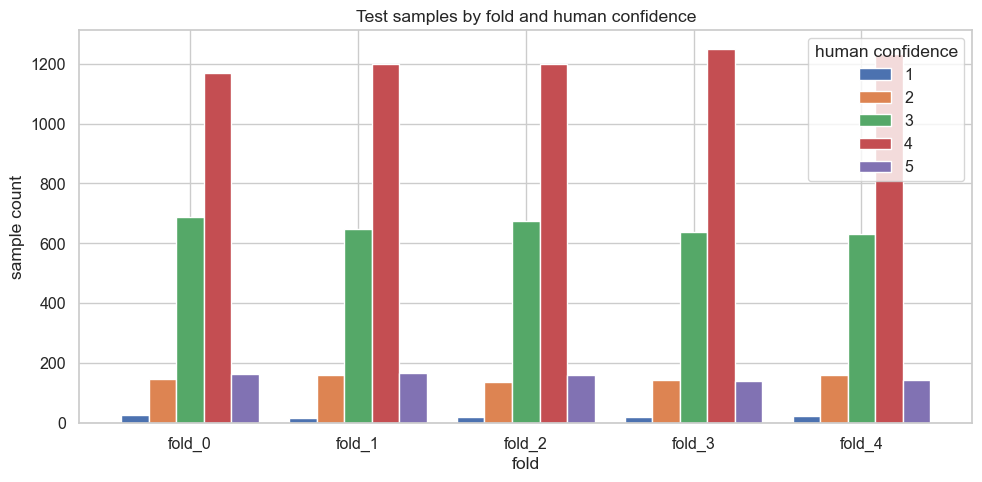

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\DCASE_task1_confidence분석\both_test_count_by_fold_and_confidence.png


result_group_ko,correct,wrong
human_confidence_level,,
1,56,50
2,415,334
3,2265,1015
4,5248,797
5,740,36


result_group_ko,correct,wrong
human_confidence_level,,
1,0.528302,0.471698
2,0.554072,0.445928
3,0.690549,0.309451
4,0.868156,0.131844
5,0.953608,0.046392


In [56]:
ax = confidence_count_by_fold.drop(index="OOF_total").plot(
    kind="bar",
    figsize=(10, 5),
    width=0.82,
)
ax.set_title("Test samples by fold and human confidence")
ax.set_xlabel("fold")
ax.set_ylabel("sample count")
ax.legend(title="human confidence")
plt.xticks(rotation=0)
plt.tight_layout()
fig_path = OUT_DIR / f"{MODE}_test_count_by_fold_and_confidence.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("saved:", fig_path)

# 저장 셀과 호환되도록 confidence level별 correct/wrong 개수와 비율도 같이 만듭니다.
group_order = ["correct", "wrong"]
conf_level_table = (
    plot_df.groupby(["human_confidence_level", "result_group_ko"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=[1, 2, 3, 4, 5], columns=group_order, fill_value=0)
)
conf_level_rate = conf_level_table.div(conf_level_table.sum(axis=1), axis=0)

display(conf_level_table)
display(conf_level_rate)

## 7. confidence별 OOF confusion matrix

전체 OOF prediction을 합친 뒤, human confidence 1~5 각각에 대해 confusion matrix를 만듭니다. 행은 실제 클래스(`ground_truth`), 열은 예측 클래스(`prediction`)입니다.

- `counts`: 원본 개수 confusion matrix
- `row_normalized`: 실제 클래스별 행 합이 1이 되도록 정규화한 matrix
- 대각선 값: 해당 confidence 구간에서 그 클래스를 맞춘 비율, 즉 class-wise recall


In [57]:
import json

confusion_out_dir = OUT_DIR / f"{MODE}_confidence_confusion_matrices"
confusion_out_dir.mkdir(parents=True, exist_ok=True)

class_dict_path = PROJECT_DIR / "data" / "class_dict.json"
if class_dict_path.exists():
    with open(class_dict_path, "r", encoding="utf-8") as f:
        class_dict_for_order = json.load(f)
    class_order = [cls for cls, _ in sorted(class_dict_for_order.items(), key=lambda item: item[1])]
else:
    class_order = sorted(set(plot_df["ground_truth"]) | set(plot_df["prediction"]))

confidence_confusion_counts = {}
confidence_confusion_row_norm = {}
confidence_class_recall_rows = []

for conf_level in [1, 2, 3, 4, 5]:
    subset = plot_df[plot_df["human_confidence_level"] == conf_level].copy()

    cm_counts = pd.crosstab(subset["ground_truth"], subset["prediction"])
    cm_counts = cm_counts.reindex(index=class_order, columns=class_order, fill_value=0)

    row_sums = cm_counts.sum(axis=1).replace(0, np.nan)
    cm_row_norm = cm_counts.div(row_sums, axis=0).fillna(0)

    confidence_confusion_counts[conf_level] = cm_counts
    confidence_confusion_row_norm[conf_level] = cm_row_norm

    cm_counts.to_csv(confusion_out_dir / f"confidence_{conf_level}_confusion_counts.csv", encoding="utf-8-sig")
    cm_row_norm.to_csv(confusion_out_dir / f"confidence_{conf_level}_confusion_row_normalized.csv", encoding="utf-8-sig")

    for true_class in class_order:
        n_true = int(cm_counts.loc[true_class].sum())
        recall = float(cm_row_norm.loc[true_class, true_class]) if true_class in cm_row_norm.columns else 0.0

        off_diag = cm_row_norm.loc[true_class].copy()
        if true_class in off_diag.index:
            off_diag.loc[true_class] = 0.0
        most_confused_class = off_diag.idxmax() if len(off_diag) else None
        most_confused_rate = float(off_diag.max()) if len(off_diag) else 0.0

        confidence_class_recall_rows.append({
            "human_confidence": conf_level,
            "true_class": true_class,
            "n_true": n_true,
            "recall_diagonal": recall,
            "most_confused_class": most_confused_class,
            "most_confused_rate": most_confused_rate,
        })

confidence_class_recall_summary = pd.DataFrame(confidence_class_recall_rows)
confidence_class_recall_summary.to_csv(
    confusion_out_dir / "confidence_class_recall_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("saved confusion matrices to:", confusion_out_dir)
display(confidence_class_recall_summary.head())

saved confusion matrices to: c:\Users\solok\Desktop\Dcase baseline\outputs\DCASE_task1_confidence분석\both_confidence_confusion_matrices


,human_confidence,true_class,n_true,recall_diagonal,most_confused_class,most_confused_rate
0,1,m-sp,5,1.000000,m-sp,0.000000
1,1,m-si,9,0.555556,is-k,0.111111
2,1,m-m,1,0.000000,ss-u,1.000000
3,1,is-p,3,0.333333,ss-u,0.666667
4,1,is-s,0,0.000000,m-sp,0.000000


## 8. 보기 편한 confidence별 confusion matrix heatmap

아래 heatmap은 row-normalized confusion matrix입니다. 각 행의 합은 1이고, 대각선이 진할수록 해당 실제 클래스를 잘 맞춘 것입니다.

먼저 클래스별 recall을 confidence 1~5로 요약한 heatmap을 보여주고, 그 다음 confidence별 상세 class confusion matrix를 보기 편한 색상과 퍼센트 주석으로 출력합니다.

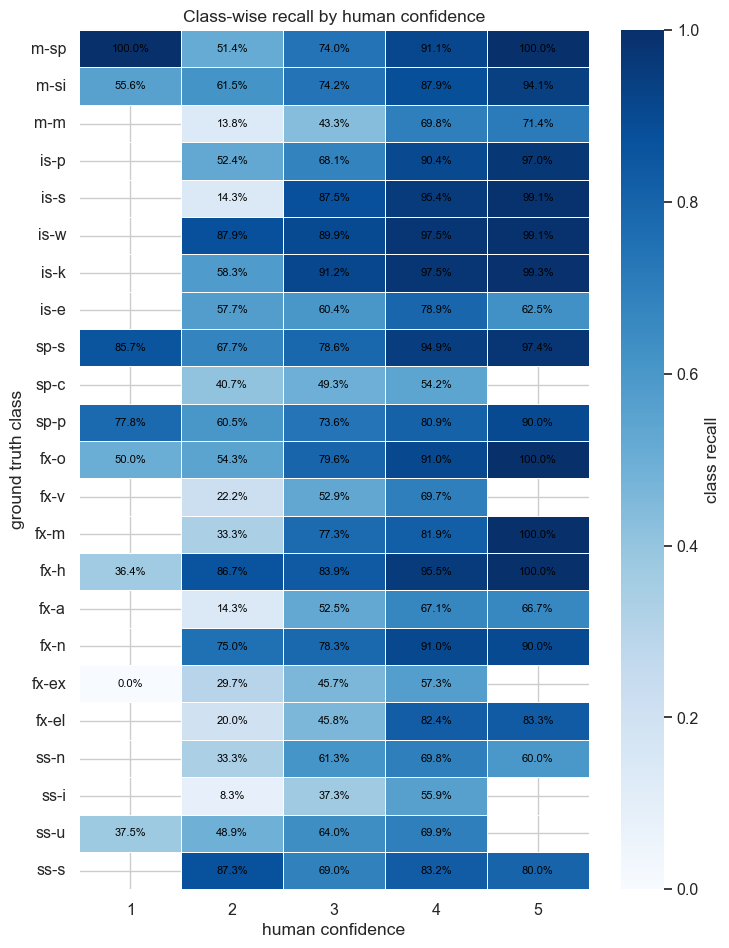

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\DCASE_task1_confidence분석\both_confidence_confusion_matrices\class_recall_by_confidence_heatmap.png


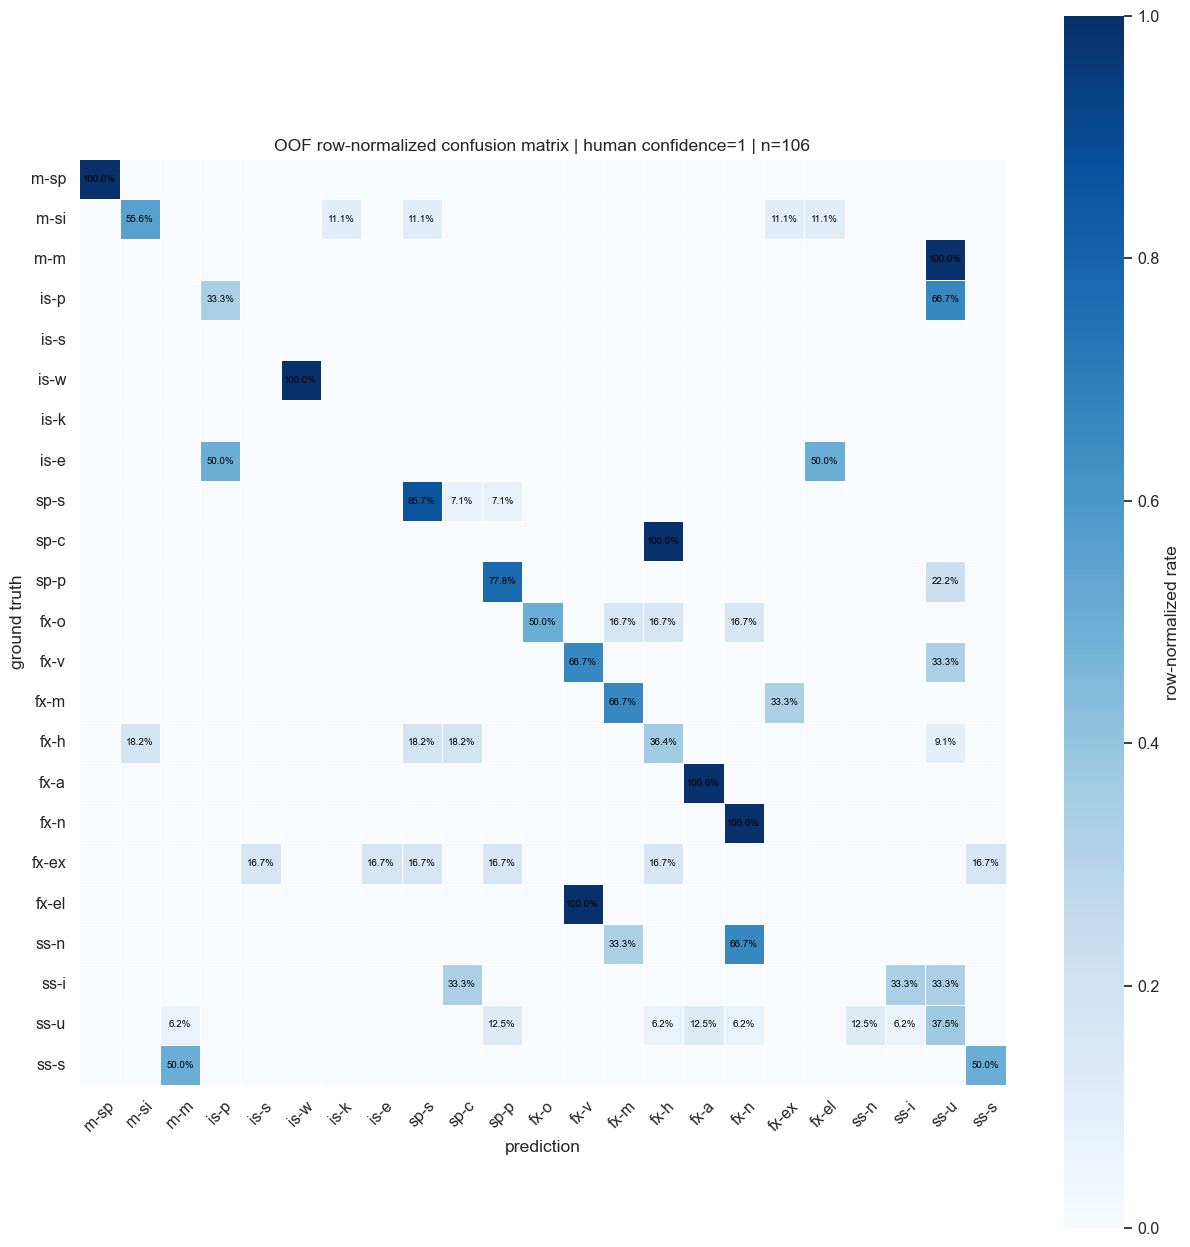

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\DCASE_task1_confidence분석\both_confidence_confusion_matrices\confidence_1_confusion_row_normalized.png


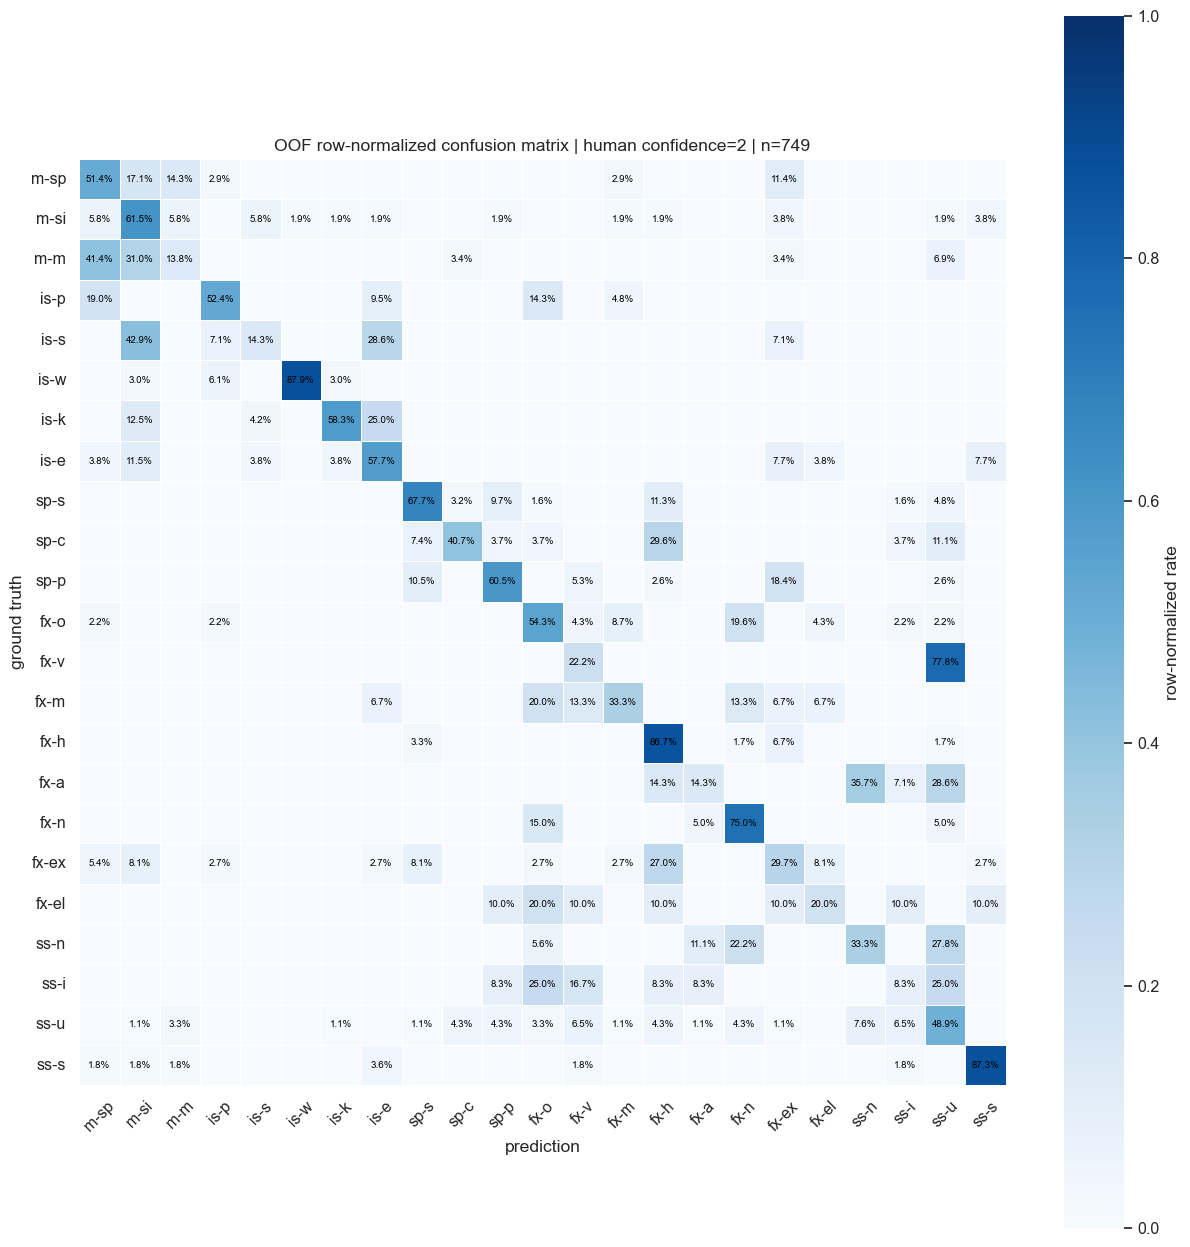

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\DCASE_task1_confidence분석\both_confidence_confusion_matrices\confidence_2_confusion_row_normalized.png


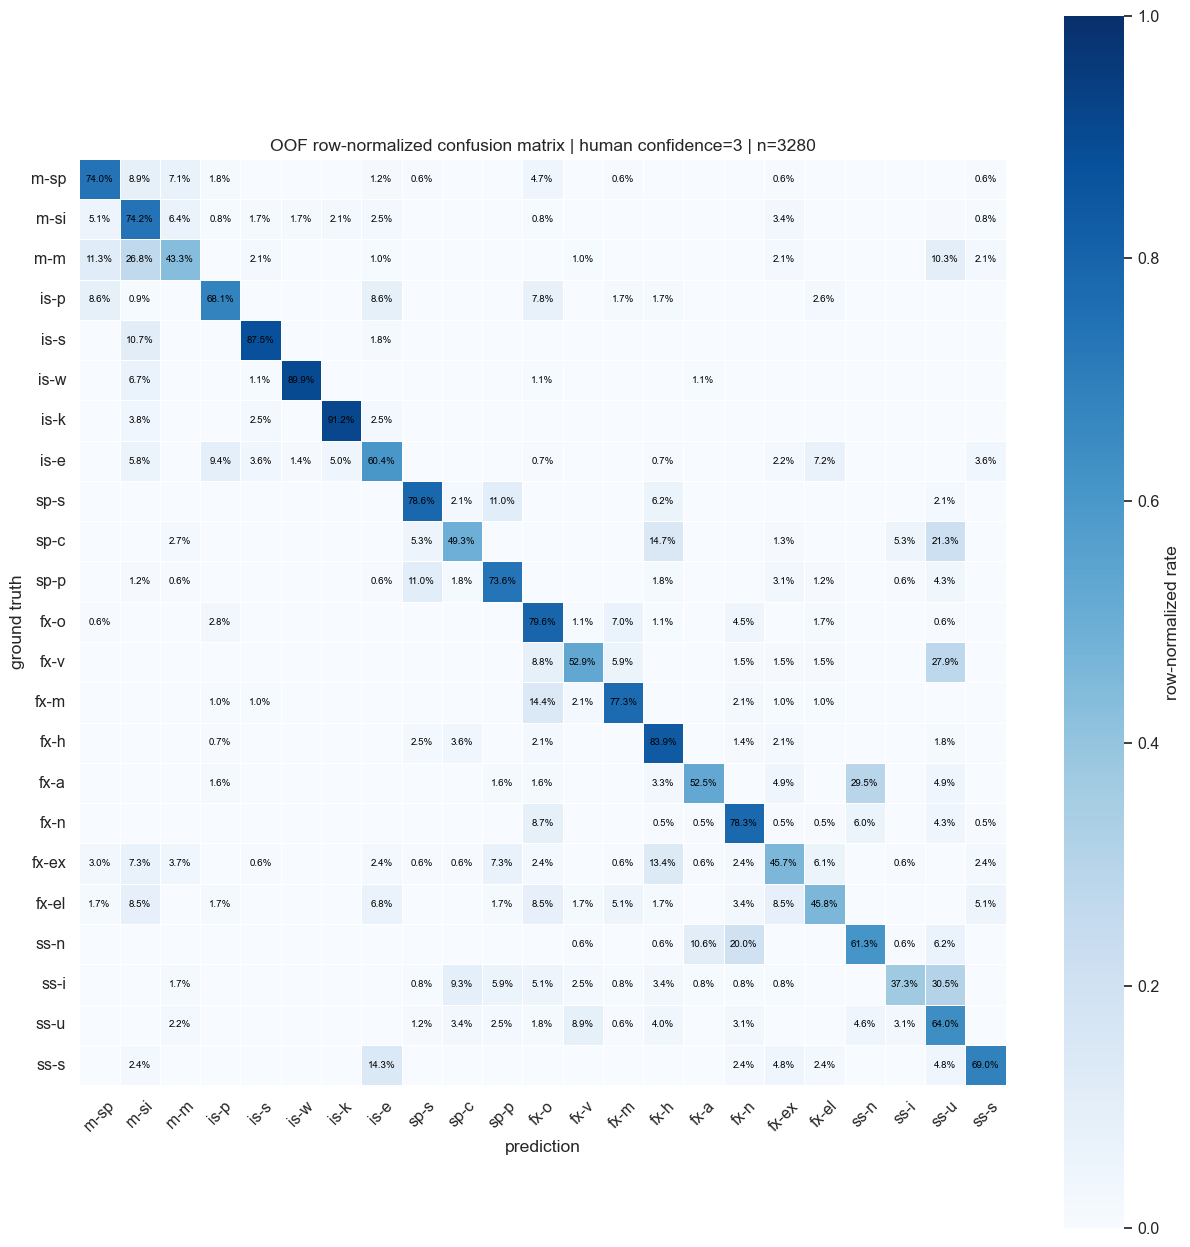

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\DCASE_task1_confidence분석\both_confidence_confusion_matrices\confidence_3_confusion_row_normalized.png


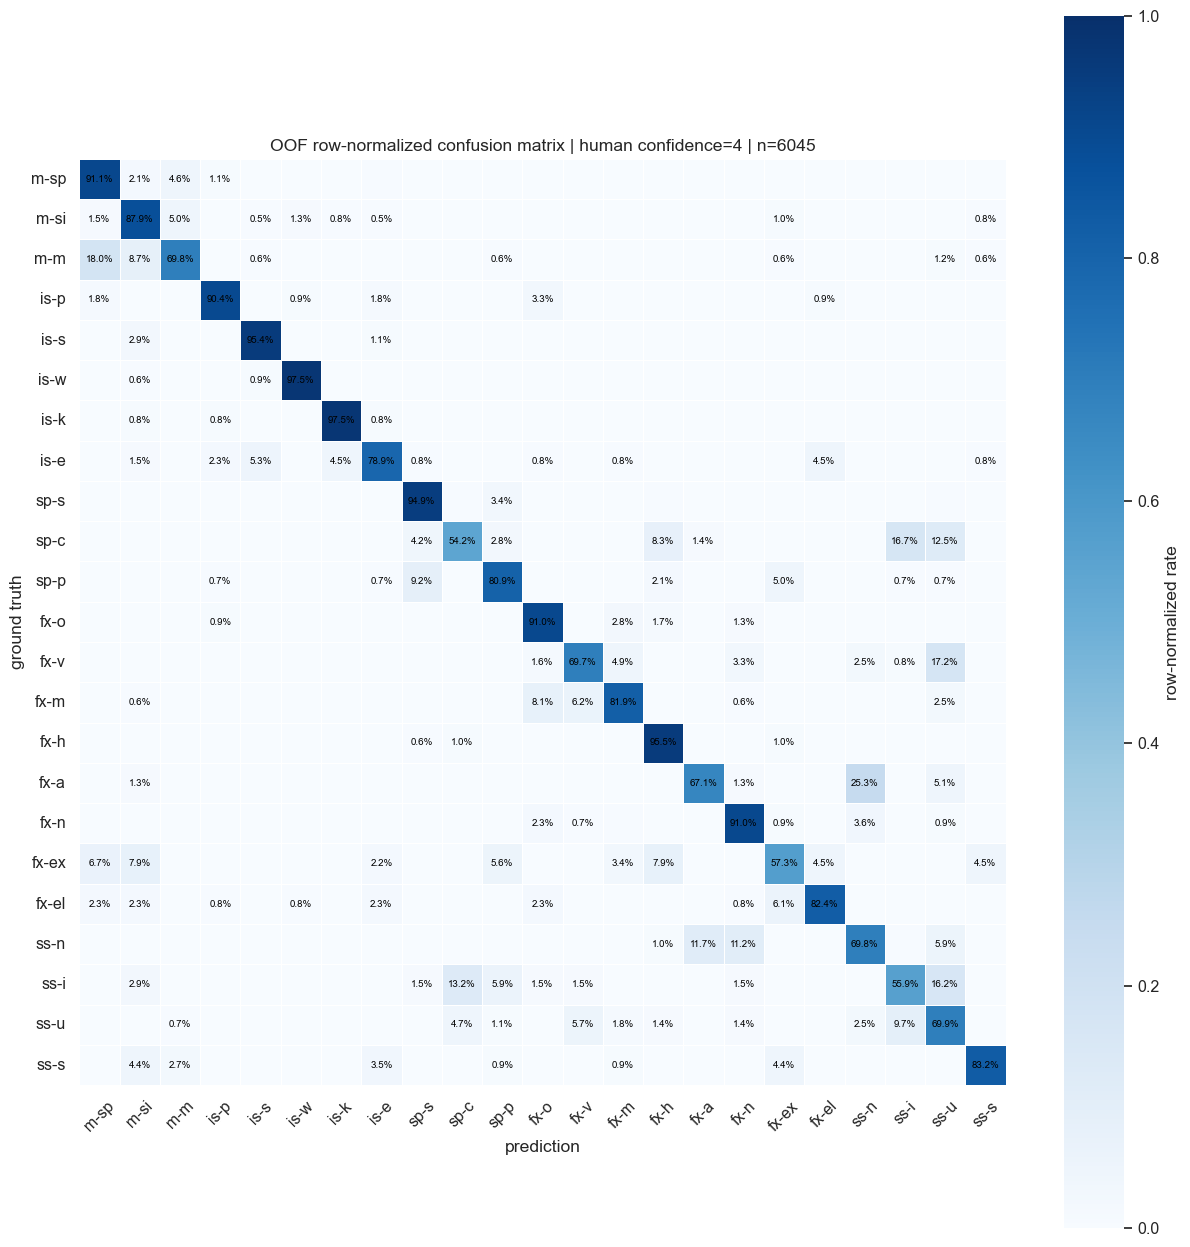

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\DCASE_task1_confidence분석\both_confidence_confusion_matrices\confidence_4_confusion_row_normalized.png


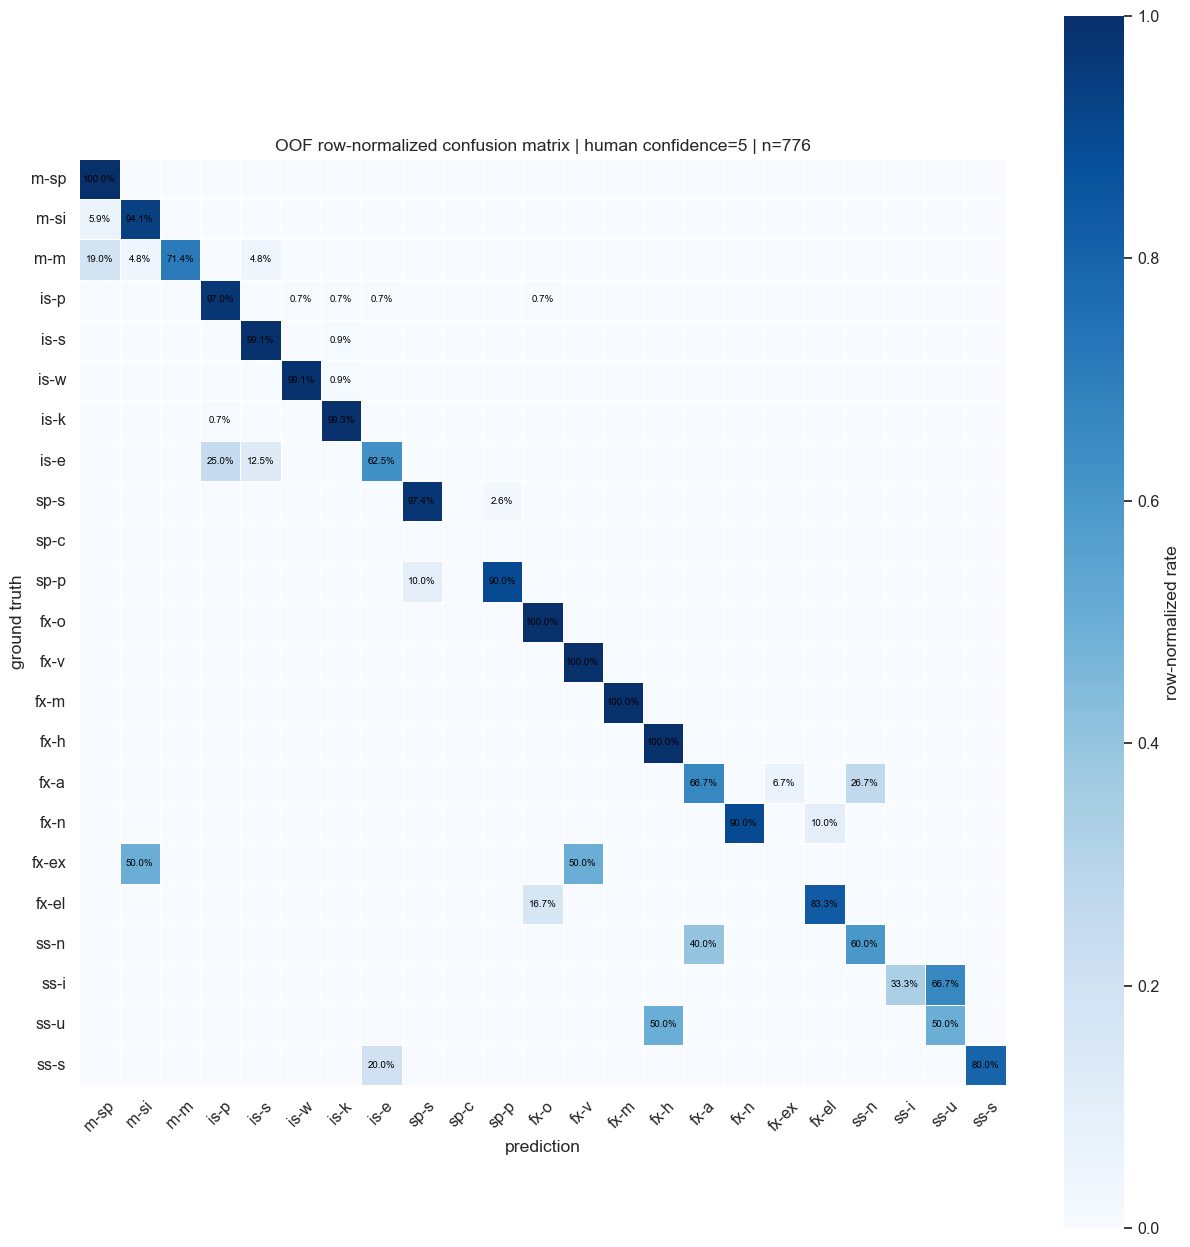

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\DCASE_task1_confidence분석\both_confidence_confusion_matrices\confidence_5_confusion_row_normalized.png


In [58]:
def percent_annot(df, min_show=0.005):
    """Return string annotations like 47.6%; very small values are left blank."""
    formatter = lambda x: "" if pd.isna(x) or x < min_show else f"{x * 100:.1f}%"
    if hasattr(df, "map"):
        return df.map(formatter)
    return df.apply(lambda col: col.map(formatter))


# 1) 클래스별 recall을 confidence별로 요약한 heatmap
recall_pivot = (
    confidence_class_recall_summary
    .pivot(index="true_class", columns="human_confidence", values="recall_diagonal")
    .reindex(index=class_order, columns=[1, 2, 3, 4, 5])
)
n_true_pivot = (
    confidence_class_recall_summary
    .pivot(index="true_class", columns="human_confidence", values="n_true")
    .reindex(index=class_order, columns=[1, 2, 3, 4, 5])
)

# 샘플이 너무 적은 칸은 해석을 피하도록 비워서 표시합니다.
MIN_HEATMAP_CLASS_COUNT = 5
recall_pivot_masked = recall_pivot.mask(n_true_pivot < MIN_HEATMAP_CLASS_COUNT)

fig_h = max(5, 0.42 * len(class_order))
fig, ax = plt.subplots(figsize=(7.5, fig_h))
if sns is not None:
    sns.heatmap(
        recall_pivot_masked,
        vmin=0,
        vmax=1,
        cmap="Blues",
        linewidths=0.7,
        linecolor="white",
        annot=percent_annot(recall_pivot_masked, min_show=0),
        fmt="",
        annot_kws={"fontsize": 8, "color": "black"},
        cbar_kws={"label": "class recall"},
        ax=ax,
    )
else:
    im = ax.imshow(recall_pivot_masked.values, vmin=0, vmax=1, cmap="Blues")
    fig.colorbar(im, ax=ax, label="class recall")
    ax.set_xticks(range(5))
    ax.set_xticklabels([1, 2, 3, 4, 5])
    ax.set_yticks(range(len(class_order)))
    ax.set_yticklabels(class_order)

ax.set_title("Class-wise recall by human confidence")
ax.set_xlabel("human confidence")
ax.set_ylabel("ground truth class")
plt.tight_layout()
fig_path = confusion_out_dir / "class_recall_by_confidence_heatmap.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
plt.show()
print("saved:", fig_path)


# 2) confidence별 상세 confusion matrix
for conf_level in [1, 2, 3, 4, 5]:
    cm_row_norm = confidence_confusion_row_norm[conf_level]
    n_samples = int(confidence_confusion_counts[conf_level].values.sum())
    annot = percent_annot(cm_row_norm, min_show=0.005)

    fig_size = max(8, 0.55 * len(class_order))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    if sns is not None:
        sns.heatmap(
            cm_row_norm,
            vmin=0,
            vmax=1,
            cmap="Blues",
            square=True,
            linewidths=0.7,
            linecolor="white",
            annot=annot,
            fmt="",
            annot_kws={"fontsize": 7, "color": "black"},
            cbar_kws={"label": "row-normalized rate"},
            ax=ax,
        )
    else:
        im = ax.imshow(cm_row_norm.values, vmin=0, vmax=1, cmap="Blues")
        ax.set_xticks(range(len(cm_row_norm.columns)))
        ax.set_xticklabels(cm_row_norm.columns, rotation=90)
        ax.set_yticks(range(len(cm_row_norm.index)))
        ax.set_yticklabels(cm_row_norm.index)
        fig.colorbar(im, ax=ax, label="row-normalized rate")

    ax.set_title(f"OOF row-normalized confusion matrix | human confidence={conf_level} | n={n_samples}")
    ax.set_xlabel("prediction")
    ax.set_ylabel("ground truth")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()

    fig_path = confusion_out_dir / f"confidence_{conf_level}_confusion_row_normalized.png"
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("saved:", fig_path)

## 9. confidence별 잘 맞춘 / 못 맞춘 클래스

In [59]:
MIN_CLASS_COUNT = 10

for conf_level in [1, 2, 3, 4, 5]:
    level_df = confidence_class_recall_summary[
        (confidence_class_recall_summary["human_confidence"] == conf_level)
        & (confidence_class_recall_summary["n_true"] >= MIN_CLASS_COUNT)
    ].copy()

    print(f"\n===== human confidence={conf_level}, n_true >= {MIN_CLASS_COUNT} =====")
    print("못 맞춘 클래스 bottom 10")
    display(
        level_df.sort_values(["recall_diagonal", "n_true"], ascending=[True, False])
        .head(10)
        .style.format({"recall_diagonal": "{:.3f}", "most_confused_rate": "{:.3f}"})
    )

    print("잘 맞춘 클래스 top 10")
    display(
        level_df.sort_values(["recall_diagonal", "n_true"], ascending=[False, False])
        .head(10)
        .style.format({"recall_diagonal": "{:.3f}", "most_confused_rate": "{:.3f}"})
    )


===== human confidence=1, n_true >= 10 =====
못 맞춘 클래스 bottom 10


,human_confidence,true_class,n_true,recall_diagonal,most_confused_class,most_confused_rate
14,1,fx-h,11,0.364,m-si,0.182
21,1,ss-u,16,0.375,sp-p,0.125
8,1,sp-s,14,0.857,sp-c,0.071


잘 맞춘 클래스 top 10


,human_confidence,true_class,n_true,recall_diagonal,most_confused_class,most_confused_rate
8,1,sp-s,14,0.857,sp-c,0.071
21,1,ss-u,16,0.375,sp-p,0.125
14,1,fx-h,11,0.364,m-si,0.182



===== human confidence=2, n_true >= 10 =====
못 맞춘 클래스 bottom 10


...

,human_confidence,true_class,n_true,recall_diagonal,most_confused_class,most_confused_rate
74,4,is-w,323,0.975,is-s,0.009
75,4,is-k,121,0.975,m-si,0.008
83,4,fx-h,618,0.955,sp-c,0.010
73,4,is-s,349,0.954,m-si,0.029
77,4,sp-s,472,0.949,sp-p,0.034
69,4,m-sp,436,0.911,m-m,0.046
85,4,fx-n,444,0.910,ss-n,0.036
80,4,fx-o,787,0.910,fx-m,0.028
72,4,is-p,334,0.904,fx-o,0.033
70,4,m-si,397,0.879,m-m,0.050



===== human confidence=5, n_true >= 10 =====
못 맞춘 클래스 bottom 10


,human_confidence,true_class,n_true,recall_diagonal,most_confused_class,most_confused_rate
107,5,fx-a,15,0.667,ss-n,0.267
94,5,m-m,21,0.714,m-sp,0.190
102,5,sp-p,10,0.900,sp-s,0.100
108,5,fx-n,10,0.900,fx-el,0.100
93,5,m-si,17,0.941,m-sp,0.059
95,5,is-p,134,0.970,is-w,0.007
100,5,sp-s,114,0.974,sp-p,0.026
96,5,is-s,109,0.991,is-k,0.009
97,5,is-w,117,0.991,is-k,0.009
98,5,is-k,134,0.993,is-p,0.007


잘 맞춘 클래스 top 10


,human_confidence,true_class,n_true,recall_diagonal,most_confused_class,most_confused_rate
92,5,m-sp,40,1.000,m-sp,0.000
98,5,is-k,134,0.993,is-p,0.007
97,5,is-w,117,0.991,is-k,0.009
96,5,is-s,109,0.991,is-k,0.009
100,5,sp-s,114,0.974,sp-p,0.026
95,5,is-p,134,0.970,is-w,0.007
93,5,m-si,17,0.941,m-sp,0.059
102,5,sp-p,10,0.900,sp-s,0.100
108,5,fx-n,10,0.900,fx-el,0.100
94,5,m-m,21,0.714,m-sp,0.190


## 10. 통계 검정

환경에 SciPy가 있으면 Mann-Whitney U test와 Welch t-test를 계산합니다.

In [60]:
correct_conf = plot_df.loc[plot_df["is_correct"], "human_confidence"].dropna()
wrong_conf = plot_df.loc[~plot_df["is_correct"], "human_confidence"].dropna()

print(f"correct mean: {correct_conf.mean():.4f} / n={len(correct_conf):,}")
print(f"wrong mean  : {wrong_conf.mean():.4f} / n={len(wrong_conf):,}")
print(f"mean diff   : {correct_conf.mean() - wrong_conf.mean():.4f}")

try:
    from scipy.stats import mannwhitneyu, ttest_ind

    mw = mannwhitneyu(correct_conf, wrong_conf, alternative="two-sided")
    tt = ttest_ind(correct_conf, wrong_conf, equal_var=False, nan_policy="omit")
    print(f"Mann-Whitney U p-value: {mw.pvalue:.6g}")
    print(f"Welch t-test p-value  : {tt.pvalue:.6g}")
except ImportError:
    print("SciPy가 설치되어 있지 않아 통계 검정은 건너뜁니다.")

correct mean: 3.7108 / n=8,724
wrong mean  : 3.1949 / n=2,232
mean diff   : 0.5159
Mann-Whitney U p-value: 1.35763e-182
Welch t-test p-value  : 2.05244e-155


## 8. 결과 저장

In [61]:
merged_path = OUT_DIR / f"{MODE}_oof_predictions_with_human_confidence.csv"
summary_path = OUT_DIR / f"{MODE}_correct_wrong_confidence_summary.csv"
level_counts_path = OUT_DIR / f"{MODE}_confidence_level_correct_wrong_counts.csv"
level_rates_path = OUT_DIR / f"{MODE}_confidence_level_correct_wrong_rates.csv"

merged.to_csv(merged_path, index=False, encoding="utf-8-sig")
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
conf_level_table.to_csv(level_counts_path, encoding="utf-8-sig")
conf_level_rate.to_csv(level_rates_path, encoding="utf-8-sig")

print("saved:", merged_path)
print("saved:", summary_path)
print("saved:", level_counts_path)
print("saved:", level_rates_path)

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\DCASE_task1_confidence분석\both_oof_predictions_with_human_confidence.csv
saved: c:\Users\solok\Desktop\Dcase baseline\outputs\DCASE_task1_confidence분석\both_correct_wrong_confidence_summary.csv
saved: c:\Users\solok\Desktop\Dcase baseline\outputs\DCASE_task1_confidence분석\both_confidence_level_correct_wrong_counts.csv
saved: c:\Users\solok\Desktop\Dcase baseline\outputs\DCASE_task1_confidence분석\both_confidence_level_correct_wrong_rates.csv
